# Analysis and Plotting script for Model 1 and Model 2.



In [61]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from os import listdir

from scipy.optimize import curve_fit
import concurrent.futures
from itertools import repeat


In [62]:
# Function definitions

def mcc(tp, tn, fp, fn):
    """ 
    Updated defnition from Wikipedia to account for case in which one of the sums in the denominator is 0 (only if two of the 4 values are 0).
    """
    nsum = np.sum(np.array([tp,tn,fp,fn]) == 0)
    if nsum < 2:
        return (tp*tn-fp*fn)/np.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))
    elif nsum == 2:
        return (tp*tn-fp*fn)
    else:
        return np.nan
    
def read_sim_output(ifile, folder, columnnames, columnnames_tcrs, dt=0.002, lifetimes_postfix = '_tcr_lifetimes_5P.json'):
    """  
    Assumes the filename starts with the following "Model9_3Phos" or so, with an underscore inbetween
    """
    _,model,_,CD45_den,pMHC_mdens,k_off,CD45_exclusion,k_CD45,k_lck,fileend= ifile.split('_')
    repeat, fileend = fileend.split('.')
    metadata = pd.DataFrame({
        'model': eval(model),
        'CD45_den':  eval(CD45_den),
        'Lck_den': 200, # hard coded in simulation
        'pMHC_mdens': eval(pMHC_mdens),
        'k_off': eval(k_off),
        'k_CD45': eval(k_CD45),
        'CD45_exclusion': eval(CD45_exclusion),
        'k_lck': eval(k_lck),
        'repeat': eval(repeat),
        }, index=[0])

    dat = pd.read_csv(folder/ifile, header=None)
    dat.columns = columnnames

    tracks = pd.read_csv(folder/ifile.replace('.txt', '_tcrs.txt'), header=None)
    tracks.columns = columnnames_tcrs
    tracks['timestep'] = (tracks['timestep']-1) * 10 + 1
    tracks['time'] = tracks['timestep'] * dt

    lifetimes = pd.read_json(folder/ifile.replace('.txt', lifetimes_postfix)) 

    return dat, tracks, metadata, lifetimes

def read_cd45_output(ifile, folder, columnnames):
    """  
    Also read the lifetime output from analysis and returns the Dataframe
    """
    _,model,_,CD45_den,pMHC_mdens,k_off,CD45_exclusion,k_CD45,k_lck,repeat,fileend= ifile.split('_')
    metadata = pd.DataFrame({
        'model': eval(model),
        'CD45_den':  eval(CD45_den),
        'Lck_den': 200, # hard coded in simulation
        'pMHC_mdens': eval(pMHC_mdens),
        'k_off': eval(k_off),
        'k_CD45': eval(k_CD45),
        'CD45_exclusion': eval(CD45_exclusion),
        'k_lck': eval(k_lck),
        'repeat': eval(repeat),
        }, index=[0])

    dat = pd.read_csv(folder/ifile, header=None)
    dat.columns = columnnames

    return dat, metadata

def check_metadata_file(file, CD45_den,pMHC_mdens,CD45_exclusion,k_CD45,k_lck, exclude_str = 'lifetimes'):
    if exclude_str in file:
        return False
    
    _,fmodel,_,fCD45_den,fpMHC_mdens,fk_off,fCD45_exclusion,fk_CD45,fk_lck,ffileend= file.split('_')

    has_CD45_den = eval(fCD45_den) in CD45_den
    has_pMHC_den = eval(fpMHC_mdens) in pMHC_mdens
    has_CD45_e = eval(fCD45_exclusion) in CD45_exclusion
    has_CD45_k = eval(fk_CD45) in k_CD45
    has_lck_k = eval(fk_lck) in k_lck

    return has_CD45_e & has_CD45_den & has_lck_k & has_CD45_k & has_pMHC_den

## Parameter estimations

In [101]:
# Theoretical TCR dwell time calculations
d_tcr  =  0.052     # um^2/s 
r_c = 0.22          # um
# From https://www.pnas.org/doi/full/10.1073/pnas.1817255116
print('TCR dwell time within close contact is {} s'.format(r_c**2/(8*d_tcr)))    # s

TCR dwell time within close contact is 0.11634615384615385 s


In [ ]:
# Binding radii and reaction rate constant calculations
# from Andrews Bray 2004: k = 4 pi D br
k_cat = 0.5    # s-1. Often used 3.41 for Lck
d = 0.113       # um^2/s 
mdens=341       # mol/um^2
print('k_cat corresponds to a binding radius of {} µm for diffusino limited irreversible reaction'.format(k_cat/(4*np.pi*(d_tcr+d))))
print('k_cat for a unimolecular reaction assuming a density of {} µm-2 corresponds to a rate constant k = {} s-µm-2 in the bimolecular case.'.format(mdens,k_cat/mdens))

k_cat corresponds to a binding radius of 0.24114385316953837 µm for an irreversible reaction
k_cat for a unimolecular reaction assuming a density of 341 µm-2 corresponds to a rate constant k = 0.001466275659824047 s-µm-2 in the bimolecular case.


In [5]:
# Mean binding time calculation
# For CD8, 3D kon = 1E5 M-1s-1
# 2D kon = 3D kon / 8.06E6 M-1 um-2 = 0.0124
# with 90000 mol/cell, and prim T cell surface area of 300 um2, CD8 density is 300 molecules/um2
print('Mean time to CD8 binding is {} s'.format(1/(0.0124*300)))
print('Mean time for Lck phosphorylation is {} s'.format(1/(3.41)))

Mean time to CD8 binding is 0.2688172043010753 s
Mean time for Lck phosphorylation is 0.29325513196480935 s


In [27]:
# Reference for the chosen value for scan time in main figure
print('Microvilli dwell time: from Cai et al., 7.69 s if in contact with APC -> used scan time = 7.5 s as reference value')

Microvilli dwell time: from Cai et al., 7.69 s if in contact with APC -> used scan time = 7.5 s as reference value


# General User Parameters

In [ ]:
fig_output_folder = '/Users/.../Sim_Figs/'

r_sim = 1 # µm
r_c = 0.22 # µm
A_c = r_c**2 * np.pi
A_out = r_sim**2 * np.pi - A_c
dt = 0.002 #s

## Model 1

In [ ]:
# Speed up version to read simulatino output file and aggregate results
# Load all json outputs into one results file

results9P_agg = pd.DataFrame()
folders = [ # results_folders
    '/Users/.../Model_1_9Phos_scan-k/',
]
file_filters = [ # all string elements in list must be in the filename
]
columnnames = ['time', 'tcrall', 'tcrbound', 'tcrp0', 'tcrp0b', 'tcrp1', 'tcrp1b', 'tcrp2', 'tcrp2b', 'tcrp3', 'tcrp3b', 'tcrp4', 'tcrp4b', 'tcrp5', 'tcrp5b', 'tcrp6', 'tcrp6b', 'tcrp7', 'tcrp7b', 'tcrp8', 'tcrp8b', 'tcrp9', 'tcrp9b']

n_sim = 100
n_P = [0,1,2,3,4,5,6,7,8,9]

for ifolder in folders:
    folder = Path(ifolder)

    for ifile in listdir(folder):
        if np.all([ifilt in ifile for ifilt in file_filters]) and ('9Phos' in ifile) and ('tcrs.txt' not in ifile): 
            _,_,_,pMHC_mdens,k_phos,sim_num= ifile.split('_')
            sim_num,_ = sim_num.split('.')
            if eval(sim_num) > n_sim:
                continue
            if eval(pMHC_mdens) == 1:
                continue
            iresult = pd.read_csv(folder/ifile, header=None)
            iresult.columns = columnnames
            
            Presult = {
                'model': 2,
                'pMHC_mdens': eval(pMHC_mdens), 
                'k_phos': eval(k_phos),
                'sim_num': eval(sim_num),
            }
            for iP in n_P:
                iresult['tcrp{}a'.format(iP)] = iresult['tcrp{}b'.format(iP)] + iresult['tcrp{}'.format(iP)]
                reached_P = np.where(iresult['tcrp{}a'.format(iP)] > 0)[0]
                if len(reached_P) > 0:
                    i_tts = iresult['time'].iat[np.min(reached_P)]
                else:
                    i_tts = np.max(iresult['time']) + 1
                Presult['time_to_{}P'.format(iP)] = i_tts,

            results9P_agg = pd.concat([results9P_agg, pd.DataFrame(Presult, index=[0])], ignore_index=True)

In [ ]:
cutoff = 7.5 # s; scan time
n_P = [0,1,2,3,4,5,6,7,8,9]

results9P_cutoff = pd.DataFrame()
for iP in n_P:
    for i_kphos in np.unique(results9P_agg['k_phos']):  
        iresult = {
                'model': 2,
                'k_phos': i_kphos,
                'n_P': iP,
        }
        no_pmhc = np.sum(results9P_agg.loc[(results9P_agg['pMHC_mdens'] == 0) & (results9P_agg['k_phos']==i_kphos), 'time_to_{}P'.format(iP)] < cutoff)
        with_pmhc = np.sum(results9P_agg.loc[(results9P_agg['pMHC_mdens'] == 10) & (results9P_agg['k_phos']==i_kphos), 'time_to_{}P'.format(iP)] < cutoff)
        tp = with_pmhc # n with pMHC_dens == 10
        fp = no_pmhc # n with pMHC_dens == 0
        fn = n_sim - with_pmhc # simnum-n with pMHC_dens == 10
        tn = n_sim - no_pmhc # simnum-n with pMHC_dens == 0

        iresult['P_n_sim_above_cutoff_nopmhc'] = no_pmhc
        iresult['P_n_sim_above_cutoff_withpmhc'] = with_pmhc
        iresult['P_tp'] = tp # n with pMHC_dens == 10
        iresult['P_fp'] = fp # n with pMHC_dens == 0
        iresult['P_fn'] = fn # simnum-n with pMHC_dens == 10
        iresult['P_tn'] = tn # simnum-n with pMHC_dens == 0
        iresult['P_tpr'] = tp/n_sim # n with pMHC_dens == 10
        iresult['P_fpr'] = fp/n_sim # n with pMHC_dens == 0
        iresult['P_mcc'] = mcc(tp, tn, fp, fn)
        iresult['P_precision'] = tp/(tp+fp)
        iresult['P_recall'] = tp/(tp+fn)
        iresult['P_tpfp'] = tp/fp
        iresult['P_tpr-fpr'] = tp/n_sim * (1-fp/n_sim)
            
        results9P_cutoff = pd.concat([results9P_cutoff, pd.DataFrame(iresult, index=[0])], ignore_index=True)


### Figure 6B

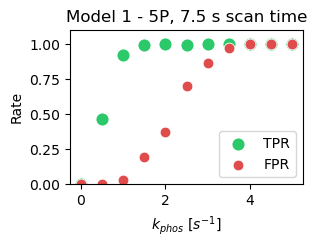

In [ ]:
fig, ax = plt.subplots(figsize = (3,2))
sns.scatterplot(
    data=results9P_cutoff[results9P_cutoff['n_P']==5],
    x='k_phos',
    y='P_tpr',
    ax = ax, 
    s=90,
    c='#2BC96A'
)
sns.scatterplot(
    data=results9P_cutoff[results9P_cutoff['n_P']==5],
    x='k_phos',
    y='P_fpr',
    ax = ax, 
    alpha=1,
    s=60,
    c='#E04B4B'
)
ax.set_ylim([0,1.1])
ax.legend(['TPR', 'FPR'])
ax.set_ylabel('Rate')
ax.set_xlabel('$k_{phos}$ [$s^{-1}$]')
ax.set_title('Model 1 - 5P, {} s scan time'.format(cutoff))
fig.savefig(fig_output_folder + 'Fig6B_Model1_5P_TPRFPR.svg')

### Figure 6C

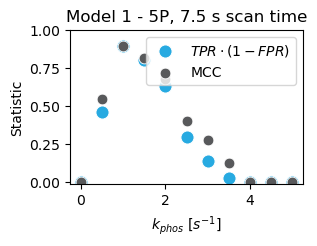

In [ ]:
fig, ax = plt.subplots(figsize = (3,2))
sns.scatterplot(
    data=results9P_cutoff[results9P_cutoff['n_P']==5],
    x='k_phos',
    y='P_tpr-fpr',
    ax = ax, 
    s=90,
    c='#27AAE1'
)
sns.scatterplot(
    data=results9P_cutoff[results9P_cutoff['n_P']==5],
    x='k_phos',
    y='P_mcc',
    ax = ax, 
    s=60,
    c='#58595B'
)
ax.set_ylim([-0.01,1])
ax.legend(['$TPR\cdot(1-FPR)$', 'MCC'])
ax.set_ylabel('Statistic')
ax.set_xlabel('$k_{phos}$ [$s^{-1}$]')
ax.set_title('Model 1 - 5P, {} s scan time'.format(cutoff))
fig.savefig(fig_output_folder + 'Fig6C_Model1_5P_stats.svg')

### Figure S8C

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that 

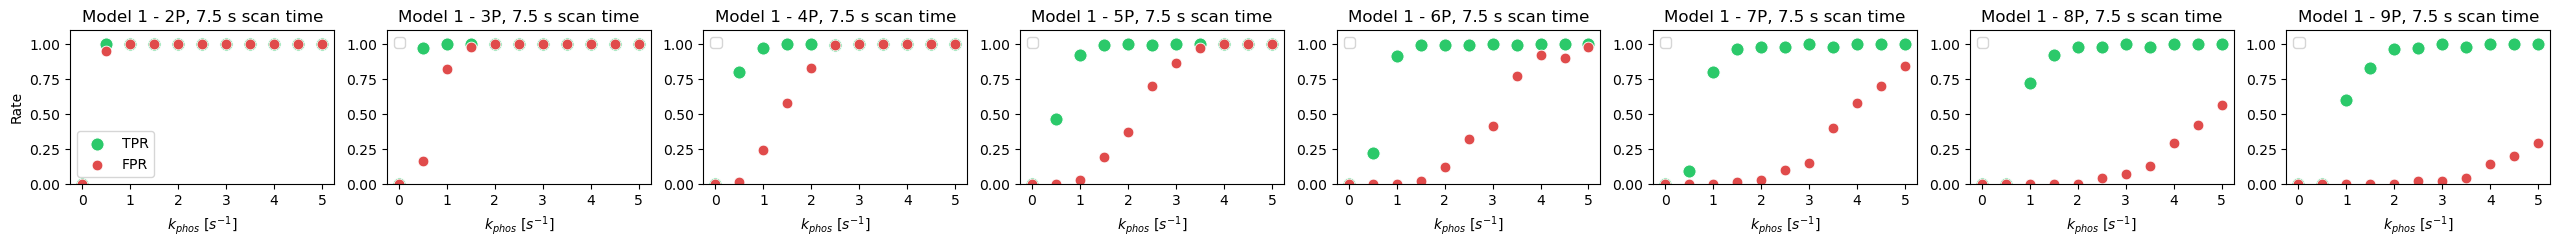

In [ ]:
n_P = [2,3,4,5,6,7,8,9]

fig, ax = plt.subplots(1,len(n_P),figsize = (4*len(n_P),2))
for i, iP in enumerate(n_P):
    sns.scatterplot(
        data=results9P_cutoff[results9P_cutoff['n_P']==iP],
        x='k_phos',
        y='P_tpr',
        ax = ax[i], 
        s=90,
        c='#2BC96A'
    )
    sns.scatterplot(
        data=results9P_cutoff[results9P_cutoff['n_P']==iP],
        x='k_phos',
        y='P_fpr',
        ax = ax[i], 
        alpha=1,
        s=60,
        c='#E04B4B'
    )
    ax[i].set_ylim([0,1.1])
    ax[i].legend(['TPR', 'FPR'])
    ax[i].set_ylabel('Rate')
    ax[i].set_xlabel('$k_{phos}$ [$s^{-1}$]')
    ax[i].set_title('Model 1 - {}P, {} s scan time'.format(iP,cutoff))
    if i>0:
        ax[i].set_ylabel('')
        ax[i].legend()
fig.savefig(fig_output_folder + 'FigS8C_Model1_9P_TPRFPR_nP.svg')

### Figure 6D

In [9]:
cutofflin = np.linspace(0,30,21) # s
n_P = [0,1,2,3,4,5,6,7,8,9]

results9P_stat = pd.DataFrame()
for iP in n_P:
    for icut in cutofflin:
        for i_kphos in np.unique(results9P_agg['k_phos']):  
            no_pmhc = np.sum(results9P_agg.loc[(results9P_agg['pMHC_mdens'] == 0) & (results9P_agg['k_phos']==i_kphos), 'time_to_{}P'.format(iP)] < icut)
            with_pmhc = np.sum(results9P_agg.loc[(results9P_agg['pMHC_mdens'] == 10) & (results9P_agg['k_phos']==i_kphos), 'time_to_{}P'.format(iP)] < icut)
            tp = with_pmhc # n with pMHC_dens == 10
            fp = no_pmhc # n with pMHC_dens == 0
            fn = n_sim - with_pmhc # simnum-n with pMHC_dens == 10
            tn = n_sim - no_pmhc # simnum-n with pMHC_dens == 0
        
            # depending on the plot, indent within kphos for loop or not
            iresult = {
                'model': 2,
                'cutoff': icut,
                'stat': tp/n_sim * (1-fp/n_sim),
                'n_P': iP,
                'k_phos': i_kphos,
                }
            results9P_stat = pd.concat([results9P_stat, pd.DataFrame(iresult, index=[0])], ignore_index=True)


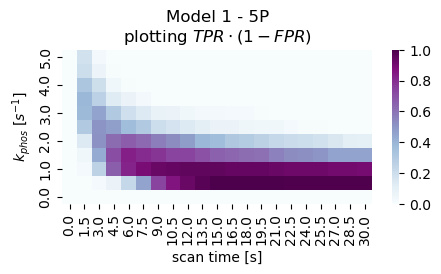

In [ ]:
fig, ax = plt.subplots(figsize=(5,2))
sns.heatmap(data = results9P_stat[results9P_stat['n_P']==5].pivot(index='k_phos',columns='cutoff',values='stat'), cmap='BuPu', square=False, vmin=0, vmax=1)
ax.set_xlabel('scan time [s]')
ax.set_ylabel('$k_{phos}$ [$s^{-1}$]')
ax.invert_yaxis()
ax.set_title('Model 1 - 5P\nplotting $TPR\cdot(1-FPR)$')
fig.savefig(fig_output_folder + 'Fig6D_Model1_5P_scan-time.svg')

### Figure S8D

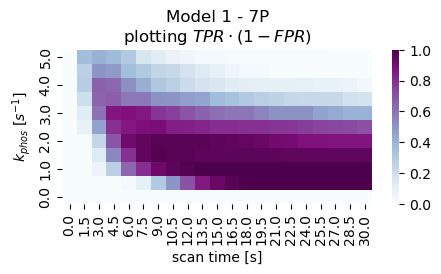

In [ ]:
fig, ax = plt.subplots(figsize=(5,2))
sns.heatmap(data = results9P_stat[results9P_stat['n_P']==7].pivot(index='k_phos',columns='cutoff',values='stat'), cmap='BuPu', square=False, vmin=0, vmax=1)
ax.set_xlabel('scan time [s]')
ax.set_ylabel('$k_{phos}$ [$s^{-1}$]')
ax.invert_yaxis()
ax.set_title('Model 1 - 7P\nplotting $TPR\cdot(1-FPR)$')
fig.savefig(fig_output_folder + 'FigS8D_Model1_9P_scan-time_7P.svg')

### Figure 6E

In [25]:
cutofflin = np.linspace(0,30,21) # s
n_P = [1,2,3,4,5,6,7]

results9P_maxstat = pd.DataFrame()
for iP in n_P:
    for icut in cutofflin:
        max_k_phos = 0
        max_stat = 0
        for i_kphos in np.unique(results9P_agg['k_phos']):  
            no_pmhc = np.sum(results9P_agg.loc[(results9P_agg['pMHC_mdens'] == 0) & (results9P_agg['k_phos']==i_kphos), 'time_to_{}P'.format(iP)] < icut)
            with_pmhc = np.sum(results9P_agg.loc[(results9P_agg['pMHC_mdens'] == 10) & (results9P_agg['k_phos']==i_kphos), 'time_to_{}P'.format(iP)] < icut)
            tp = with_pmhc # n with pMHC_dens == 10
            fp = no_pmhc # n with pMHC_dens == 0
            fn = n_sim - with_pmhc # simnum-n with pMHC_dens == 10
            tn = n_sim - no_pmhc # simnum-n with pMHC_dens == 0

            if tp/n_sim * (1-fp/n_sim) > max_stat:
                max_k_phos = i_kphos
                max_stat = tp/n_sim * (1-fp/n_sim)
        
        iresult = {
            'model': 2,
            'cutoff': icut,
            'max_k_phos': max_k_phos,
            'max_stat': max_stat,
            'stat': tp/n_sim * (1-fp/n_sim),
            'n_P': iP,
            }
        results9P_maxstat = pd.concat([results9P_maxstat, pd.DataFrame(iresult, index=[0])], ignore_index=True)


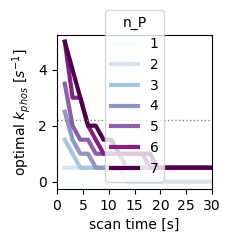

In [ ]:
n_P = [3,4,5,6,7]

fig, ax = plt.subplots(figsize=(2,2)) 
sns.lineplot(data = results9P_maxstat[(results9P_maxstat['cutoff']>0)], x = 'cutoff', y='max_k_phos', hue='n_P', ax=ax, palette='BuPu', lw=3)
ax.plot([0,30], [2.2,2.2], lw=1, ls=':', c='gray')
ax.set_xlabel('scan time [s]')
ax.set_ylabel('optimal $k_{phos}$ [$s^{-1}$]')
ax.set_xlim(0,30)
ax.set_xticks([0,5,10,15,20,25,30])
fig.savefig(fig_output_folder + 'Fig6E_Model1_5P_optimal_k-phos.svg')

In [116]:
results9P_maxstat[(results9P_maxstat['cutoff']<7.5) & (results9P_maxstat['max_k_phos']<=2.5) & (results9P_maxstat['max_k_phos'] >= 2) ]

,model,cutoff,max_k_phos,max_stat,stat,n_P
64,2,1.5,2.5,0.3234,0.0099,4
86,2,3.0,2.0,0.5082,0.0300,5
109,2,6.0,2.0,0.8633,0.0400,6
130,2,6.0,2.0,0.9118,0.3000,7


### Fig S8B

In [44]:
# Number of TCRs over time, single simulation
n_sim = 100
n_P = [0,1,2,3,4,5,6,7,8,9]


ifile = 'model_2_9Phos_10_2.0_{}.txt'.format(n_sim)
_,_,_,pMHC_mdens,k_phos,sim_num= ifile.split('_')
sim_num,_ = sim_num.split('.')
tcr_timecourse = pd.read_csv(folder/ifile, header=None)
tcr_timecourse.columns = columnnames
for iP in n_P:
    tcr_timecourse['tcrp{}all'.format(iP)] = tcr_timecourse['tcrp{}'.format(iP)] + tcr_timecourse['tcrp{}b'.format(iP)]

for isim in range(n_sim-1):
    ifile = 'model_2_9Phos_10_2.0_{}.txt'.format(isim+1)
    _,_,_,pMHC_mdens,k_phos,sim_num= ifile.split('_')
    sim_num,_ = sim_num.split('.')
    iresult = pd.read_csv(folder/ifile, header=None)
    iresult.columns = columnnames
    for iP in n_P:
        tcr_timecourse['tcrp{}all'.format(iP)] = tcr_timecourse['tcrp{}all'.format(iP)] + iresult['tcrp{}'.format(iP)] + iresult['tcrp{}b'.format(iP)]

for iP in n_P:
        tcr_timecourse['tcrp{}all'.format(iP)] = tcr_timecourse['tcrp{}all'.format(iP)]/n_sim

1.0
0.9
0.5
0.19999999999999996
0.09999999999999998


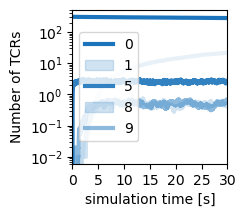

In [ ]:
n_P = [0,1,5,8,9]

fig, ax = plt.subplots(figsize=(2,2)) 
for iP in n_P:
    sns.lineplot(data = tcr_timecourse, x = 'time', y='tcrp{}all'.format(iP), ax=ax, c='#1C75BC', lw=3, alpha=1-iP*0.1)
    print(1-iP*0.1)
ax.set_xlabel('simulation time [s]')
ax.set_ylabel('Number of TCRs')
ax.set_xlim(0,30)
ax.set_xticks([0,5,10,15,20,25,30])
ax.set_yscale('log')
ax.legend(['{}'.format(i) for i in n_P])
fig.savefig(fig_output_folder + 'FigS8B_Model1_9P_tcr-numbers.svg')

## Model 2

In [ ]:
# User input
folder = "/Users/.../Model_2_5Phos_scan-k/"
columnnames_tcrs = ['timestep', 'species_type', 'state', 'x', 'y', 'sn']
columnnames = ['time', 'tcr', 'tcrb', 'tcrp1', 'tcrp1b', 'tcrp2', 'tcrp2b', 'tcrp3', 'tcrp3b', 'tcrp4', 'tcrp4b', 'tcrp5', 'tcrp5b', 'tcrall', 'cd45all'] 

simtime = 30 # s
output_n = 10   # how often the lifetimes simulation output has been saved, in timesteps
n_sim = 50

In [ ]:
filelist = [i for i in listdir(folder) if ('tcrs' not in i) & ('lifetimes' not in i) & ('model_2' in i)]
filelist = np.sort(filelist)
folder = Path(folder)

In [ ]:
# Load triggering times
# Run lifetimes calculations separately, then read in output here
alldat = pd.DataFrame()

k_CD45 = [0.05, 0.01, 0.005, 0.001] # s-1 um-2
k_lck = [0.05, 0.01, 0.005, 0.001] # s-1 um-2
CD45_den = [600]
pMHC_mdens = [0,10]
CD45_exclusion = [0,20,40,60,80,100]

triggering = pd.DataFrame()

for ifile in filelist:
    if check_metadata_file(ifile, CD45_den,pMHC_mdens,CD45_exclusion,k_CD45,k_lck):
        print(ifile)
        dat, tracks, metadata, lifetimes = read_sim_output(ifile, folder, columnnames, columnnames_tcrs, dt=dt, lifetimes_postfix='_tcr_lifetimes_5P_0.3.json')

        # All TCRPn
        tcrp5_trig_time = [i for i in lifetimes['tcrp5_trig_times'].values[0] if (i != False)] # to consider all triggering TCRs
        #trigtimes_p3 = lifetimes['tcrp3_trig_times'].values[0]
        #tcrp3_trig_time = [trigtimes_p3[i] for i in range(len(trigtimes_p3)) if ((trigtimes_p3[i] != False) and (lifetimes['tcrp3_trig_inside'].values[0][i]))] # to consider triggering TCRs only inside the contact
        if len(tcrp5_trig_time) > 0:
            tcrp5_trig_time = np.min(tcrp5_trig_time)*dt*output_n
        else:
            tcrp5_trig_time = simtime + 1
        tcrp5_lifetimes_inside_mean = lifetimes['tcrp5_lifetimes_inside'].values[0]
        if len(tcrp5_lifetimes_inside_mean) > 0:
            tcrp5_lifetimes_inside_mean = np.mean(tcrp5_lifetimes_inside_mean)*dt*output_n
        else: 
            tcrp5_lifetimes_inside_mean = 0

        # Bound TCRPn
        tcrp5b_trig_time = [i for i in lifetimes['tcrp5b_trig_times'].values[0] if (i != False)] # to consider only bound triggering TCRs
        #trigtimes_p3b = lifetimes['tcrp3b_trig_times'].values[0]
        #tcrp3b_trig_time = [trigtimes_p3b[i] for i in range(len(trigtimes_p3b)) if ((trigtimes_p3b[i] != False) and (lifetimes['tcrp3b_trig_inside'].values[0][i]))] # to consider triggering TCRs only inside the contact
        if len(tcrp5b_trig_time) > 0:
            tcrp5b_trig_time = np.min(tcrp5b_trig_time)*dt*output_n
        else:
            tcrp5b_trig_time = simtime + 1
        tcrp5b_lifetimes_inside_mean = lifetimes['tcrp5b_lifetimes_inside'].values[0]
        if len(tcrp5b_lifetimes_inside_mean) > 0:
            tcrp5b_lifetimes_inside_mean = np.mean(tcrp5b_lifetimes_inside_mean)*dt*output_n
        else: 
            tcrp5b_lifetimes_inside_mean = 0

        # Create dict
        trig = {
            'model': metadata['model'].values[0],
            'CD45_den':  metadata['CD45_den'].values[0],
            'pMHC_mdens': metadata['pMHC_mdens'].values[0],
            'k_off': metadata['k_off'].values[0],
            'k_CD45': metadata['k_CD45'].values[0],
            'CD45_exclusion': metadata['CD45_exclusion'].values[0],
            'k_lck': metadata['k_lck'].values[0],
            'repeat': metadata['repeat'].values[0],
            'tcrp5_trig_time': tcrp5_trig_time,
            'tcrp5b_trig_time': tcrp5b_trig_time,
            'tcrp5_lifetimes_inside_mean': tcrp5_lifetimes_inside_mean,
            'tcrp5b_lifetimes_inside_mean': tcrp5b_lifetimes_inside_mean,
        }
        triggering = pd.concat([triggering, pd.DataFrame(trig, index=[0])], ignore_index=True)




In [434]:
scan_time = 10 # s

avgtrig = pd.DataFrame()
for ik in k_CD45:
    for jk in k_lck:
        for id in CD45_den:
            for ie in CD45_exclusion:
                cond_pos = (triggering['k_CD45']==ik) & (triggering['k_lck']==jk) & (triggering['CD45_den']==id) & (triggering['CD45_exclusion']==ie) & (triggering['pMHC_mdens']==10)
                cond_neg = (triggering['k_CD45']==ik) & (triggering['k_lck']==jk) & (triggering['CD45_den']==id) & (triggering['CD45_exclusion']==ie) & (triggering['pMHC_mdens']==0)
                tp = np.sum(triggering.loc[cond_pos,'tcrp5_trig_time']<scan_time)
                fn = np.sum(triggering.loc[cond_pos,'tcrp5_trig_time']>=scan_time)
                fp = np.sum(triggering.loc[cond_neg,'tcrp5_trig_time']<scan_time)
                tn = np.sum(triggering.loc[cond_neg,'tcrp5_trig_time']>=scan_time)
                tpr = tp / len(triggering.loc[cond_pos,'tcrp5_trig_time'])
                fpr = fp / len(triggering.loc[cond_neg,'tcrp5_trig_time'])
                stat_mcc = mcc(tp, tn, fp, fn)
                
                avg = {
                    'k_CD45': ik,
                    'k_lck': jk,
                    'CD45_den': id,
                    'CD45_exclusion': ie,
                    'tcrp5_trig_time_mean_pos': np.mean(triggering.loc[cond_pos,'tcrp5_trig_time']),
                    'tcrp5b_trig_time_mean_pos': np.mean(triggering.loc[cond_pos,'tcrp5b_trig_time']),
                    'tcrp5_trig_time_mean_neg': np.mean(triggering.loc[cond_neg,'tcrp5_trig_time']),
                    'tcrp5b_trig_time_mean_neg': np.mean(triggering.loc[cond_neg,'tcrp5b_trig_time']),
                    'tp': tp,
                    'fn': fn, 
                    'tn': tn,
                    'fp': fp,
                    'tpr': tpr,
                    'fpr': fpr,
                    'stat': tpr * (1-fpr),
                    'mcc': stat_mcc,
                }
                avgtrig = pd.concat([avgtrig, pd.DataFrame(avg, index=[0])], ignore_index=True)

### Figure 6F

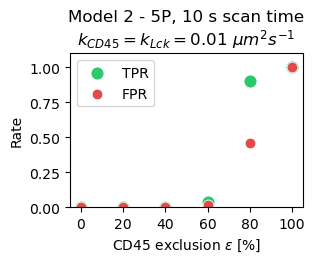

In [ ]:
fig, ax = plt.subplots(figsize = (3,2))

cond = (avgtrig['k_CD45']==0.01) & (avgtrig['k_lck']==0.01) & (avgtrig['CD45_den']==600)

sns.scatterplot(
    data=avgtrig.loc[cond],
    x='CD45_exclusion',
    y='tpr',
    ax = ax, 
    s=90,
    c='#2BC96A'
)
sns.scatterplot(
    data=avgtrig.loc[cond],
    x='CD45_exclusion',
    y='fpr',
    ax = ax, 
    alpha=1,
    s=60,
    c='#E04B4B'
)
ax.set_ylim([0,1.1])
ax.legend(['TPR', 'FPR'])
ax.set_ylabel('Rate')
ax.set_xlabel('CD45 exclusion $\epsilon$ [%]')
ax.set_title('Model 2 - 5P, 10 s scan time\n$k_{CD45} = k_{Lck} = 0.01$ $µm^2 s^{-1}$')
ax.set_xticks([0,20,40,60,80,100])
ax.set_xticklabels(['0','20','40','60','80','100'])
fig.savefig(fig_output_folder + 'Fig6F_Model2_5P_TPRFPR.svg')

### Figure 6G

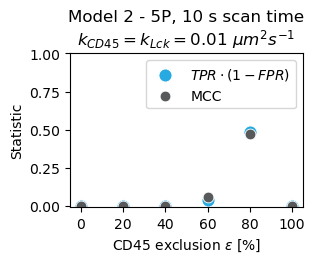

In [ ]:
fig, ax = plt.subplots(figsize = (3,2))

cond = (avgtrig['k_CD45']==0.01) & (avgtrig['k_lck']==0.01) & (avgtrig['CD45_den']==600)

sns.scatterplot(
    data=avgtrig.loc[cond],
    x='CD45_exclusion',
    y='stat',
    ax = ax, 
    s=90,
    c='#27AAE1'
)
sns.scatterplot(
    data=avgtrig.loc[cond],
    x='CD45_exclusion',
    y='mcc',
    ax = ax, 
    alpha=1,
    s=60,
    c='#58595B'
)
ax.set_ylim([-0.01,1])
ax.legend(['$TPR\cdot(1-FPR)$', 'MCC'])
ax.set_ylabel('Statistic')
ax.set_xlabel('CD45 exclusion $\epsilon$ [%]')
ax.set_title('Model 2 - 5P, 10 s scan time\n$k_{CD45} = k_{Lck} = 0.01$ $µm^2 s^{-1}$')
ax.set_xticks([0,20,40,60,80,100])
ax.set_xticklabels(['0','20','40','60','80','100'])
fig.savefig(fig_output_folder + 'Fig6G_Model2_5P_Stats.svg')

### Figure 6H

In [432]:
k_CD45 = [0.001,0.005,0.01,0.05] # s-1 um-2 [0.001,0.005,0.01,0.05] #
k_lck = [0.001,0.005,0.01,0.05] # s-1 um-2 [0.001,0.005,0.01,0.05] #
excl = [0,20,40,60,80,100]

trigmat = np.zeros((4,4,6))

for i, i_CD45 in enumerate(k_CD45):
    for j, j_exc in enumerate(excl):
        for m, m_lck in enumerate(k_lck):
            cond = (avgtrig['k_CD45']==i_CD45) & (avgtrig['CD45_exclusion']==j_exc) & (avgtrig['CD45_den']==600) & (avgtrig['k_lck']==m_lck)
            trigmat[i,m,j] = avgtrig.loc[cond, 'stat'].values[0]

# get exclusino value at maximum stat

max_exclusion = np.zeros((4,4))
for i, i_CD45 in enumerate(k_CD45):
    for m, m_lck in enumerate(k_lck):
        max_exclusion[i,m] = np.argmax(trigmat[i,m,:])*20

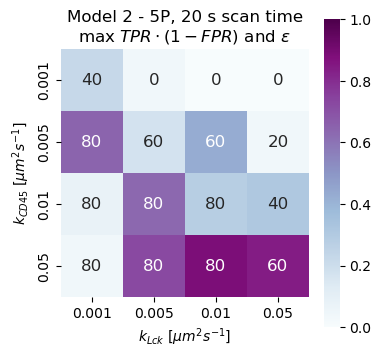

In [ ]:
fig, ax = plt.subplots(figsize=(4,4))
sns.heatmap(np.max(trigmat, axis=2), square=True, ax=ax, cmap='BuPu', annot = max_exclusion, annot_kws={'fontsize':12}, vmin=0, vmax=1)
ax.set_xticklabels([0.001,0.005,0.01,0.05])
ax.set_yticklabels([0.001,0.005,0.01,0.05])
ax.set_title('Model 2 - 5P, {} s scan time\nmax $TPR\cdot(1-FPR)$ and $\epsilon$'.format(scan_time))
ax.set_xlabel('$k_{Lck}$ [$µm^2 s^{-1}$]')
ax.set_ylabel('$k_{CD45}$ [$µm^2 s^{-1}$]')
fig.savefig(fig_output_folder + 'Fig6H_Model2_5P_scantime{}s.svg'.format(scan_time))

### Fig S8E

In [ ]:
# CD45 exclusion for varying p_in
# for kCD45 = kLck = 0.01, no pMHC

folder = "/Users/.../Model_2_5Phos_scan-e/"

filelist = [i for i in listdir(folder) if ('cd45' in i) & ('model_2' in i)]
filelist = np.sort(filelist)
folder = Path(folder)

columnnames_cd45 = ['timestep', 'species_type', 'state', 'x', 'y', 'sn']

k_CD45 = 0.01 # s-1 um-2
k_lck = 0.01 # s-1 um-2
CD45_den = 600
pMHC_mdens = 0
CD45_exclusion = [0,20,40,60,80,100]
simtime = 30 # s
dt = 0.002 # s
output_freq = 100 # timesteps
n_sim = 50

# Prepare DataFrame
avgdat = pd.DataFrame()
for ie in CD45_exclusion:
    avg = {
        'time': np.linspace(0,simtime,int(simtime/(dt*output_freq))+1),
        'k_CD45': np.repeat(k_CD45,int(simtime/(dt*output_freq))+1),
        'k_lck': np.repeat(k_lck,int(simtime/(dt*output_freq))+1),
        'CD45_den': np.repeat(CD45_den,int(simtime/(dt*output_freq))+1),
        'CD45_excl': np.repeat(ie,int(simtime/(dt*output_freq))+1),
        'tcr0': np.repeat(0,int(simtime/(dt*output_freq))+1),
        'tcr1': np.repeat(0,int(simtime/(dt*output_freq))+1),
        'tcr2': np.repeat(0,int(simtime/(dt*output_freq))+1),
        'tcr3': np.repeat(0,int(simtime/(dt*output_freq))+1),
        'cd45i': np.repeat(0,int(simtime/(dt*output_freq))+1),
        'cd45o': np.repeat(0,int(simtime/(dt*output_freq))+1),
        'cd45_sum': np.repeat(0,int(simtime/(dt*output_freq))+1),
    }
    avgdat = pd.concat([avgdat, pd.DataFrame(avg)], ignore_index=True)

# Add values for each simulation, then divide to get the mean
single_traces = []
for ifile in filelist:
    dat, metadata = read_cd45_output(ifile, folder, columnnames_cd45)
    if metadata['pMHC_mdens'].values[0] != pMHC_mdens:
        continue
    print(ifile)
    dat['distance'] = np.sqrt(dat['x']**2 + dat['y']**2)
    dat['inside'] = dat['distance']<r_c
    cd45i = []
    cd45o = []
    for i in np.unique(dat['timestep']):
        cd45i.append(np.sum(dat.loc[dat['timestep'] == i, 'inside'] == True))
        cd45o.append(np.sum(dat.loc[dat['timestep'] == i, 'inside'] == False))

    cond = (avgdat['k_CD45']==metadata['k_CD45'].values[0]) & (avgdat['k_lck']==metadata['k_lck'].values[0]) & (avgdat['CD45_den']==metadata['CD45_den'].values[0]) & (avgdat['CD45_excl']==metadata['CD45_exclusion'].values[0])
    avgdat.loc[cond,'cd45i'] += np.array(cd45i)
    avgdat.loc[cond,'cd45o'] += np.array(cd45o)
    avgdat.loc[cond,'cd45_sum'] += (np.array(cd45o) + np.array(cd45i))
    if (metadata['pMHC_mdens'].values[0] != 0) | (metadata['repeat'].values[0] == 1):
        exclusion = (1-np.array(cd45i)*A_out/(np.array(cd45o)*A_c))*100
        single_traces.append(exclusion)

avgdat['cd45i'] = avgdat['cd45i']/n_sim
avgdat['cd45o'] = avgdat['cd45o']/n_sim
avgdat['cd45_sum'] = avgdat['cd45_sum']/n_sim
avgdat['cd45_simex'] = (1-avgdat['cd45i']*A_out/(avgdat['cd45o']*A_c))*100


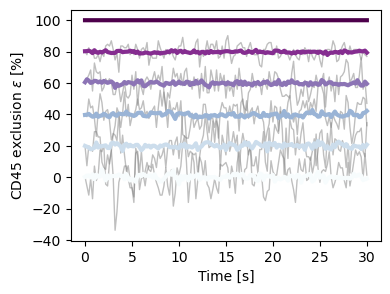

In [ ]:
fig, ax = plt.subplots(figsize=(4,3))
for itrace in single_traces:
    sns.lineplot(x=np.linspace(0,simtime,int(simtime/(dt*output_freq))+1), y=itrace, c='Grey', ax=ax, lw=1, alpha=0.5)
sns.lineplot(data=avgdat, x='time', y='cd45_simex', hue='CD45_excl', palette='BuPu', ax=ax, lw=3, legend=False)

ax.set_xlabel('Time [s]')
ax.set_ylabel('CD45 exclusion $\epsilon$ [%]')
fig.savefig(fig_output_folder + 'FigS8E_Model2_5P_exclusion.svg')

### Fig S8F

In [ ]:
# TCR numbers over time 
# for kCD45 = kLck = 0.01, n

folder = "/Users/.../Model_2_5Phos_scan-e/"

filelist = [i for i in listdir(folder) if ('tcrs.txt' not in i) & ('model_2' in i) & ('lifetimes_5P' not in i)]
filelist = np.sort(filelist)
folder = Path(folder)

columnnames = ['time', 'tcr', 'tcrb', 'tcrp1', 'tcrp1b', 'tcrp2', 'tcrp2b', 'tcrp3', 'tcrp3b', 'tcrp4', 'tcrp4b', 'tcrp5', 'tcrp5b', 'tcrall', 'cd45all'] 
columnnames_tcrs = ['timestep', 'species_type', 'state', 'x', 'y', 'sn']


k_CD45 = 0.01 # s-1 um-2
k_lck = 0.01 # s-1 um-2
CD45_den = 600
pMHC_mdens = [0]
CD45_exclusion = [0,20,40,60,80,100]
n_sim = 50

alldat = pd.DataFrame()
avgdat = pd.DataFrame()
for ie in CD45_exclusion:
    avg = {
        'time': np.linspace(0,simtime,int(simtime/dt)+1),
        'k_CD45': np.repeat(k_CD45,int(simtime/dt)+1),
        'k_lck': np.repeat(k_lck,int(simtime/dt)+1),
        'CD45_den': np.repeat(CD45_den,int(simtime/dt)+1),
        'CD45_excl': np.repeat(ie,int(simtime/dt)+1),
        'tcr0': np.repeat(0,int(simtime/dt)+1),
        'tcr1': np.repeat(0,int(simtime/dt)+1),
        'tcr2': np.repeat(0,int(simtime/dt)+1),
        'tcr3': np.repeat(0,int(simtime/dt)+1),
        'tcr4': np.repeat(0,int(simtime/dt)+1),
        'tcr5': np.repeat(0,int(simtime/dt)+1),
        'tcrall': np.repeat(0,int(simtime/dt)+1),
        'tcr5i': np.repeat(0,int(simtime/dt)+1),
        'tcr5o': np.repeat(0,int(simtime/dt)+1),
    }
    avgdat = pd.concat([avgdat, pd.DataFrame(avg)], ignore_index=True)


for ifile in filelist:
    if '_cd45.txt' in ifile:
        continue
    if check_metadata_file(ifile, [CD45_den],pMHC_mdens,CD45_exclusion,[k_CD45],[k_lck]):
        print(ifile)
        dat, tracks, metadata, _ = read_sim_output(ifile, folder, columnnames, columnnames_tcrs, dt=dt, lifetimes_postfix = '_tcr_lifetimes_5P_0.1.json')

        alldat = pd.concat([alldat, dat], ignore_index=True)
        cond = (avgdat['k_CD45']==metadata['k_CD45'].values[0]) & (avgdat['k_lck']==metadata['k_lck'].values[0]) & (avgdat['CD45_den']==metadata['CD45_den'].values[0]) & (avgdat['CD45_excl']==metadata['CD45_exclusion'].values[0])
        avgdat.loc[cond,'tcr0'] += dat['tcr'].values
        avgdat.loc[cond,'tcr1'] += dat['tcrp1'].values
        avgdat.loc[cond,'tcr2'] += dat['tcrp2'].values
        avgdat.loc[cond,'tcr3'] += dat['tcrp3'].values
        avgdat.loc[cond,'tcr4'] += dat['tcrp4'].values
        avgdat.loc[cond,'tcr5'] += dat['tcrp5'].values
        avgdat.loc[cond,'tcrall'] += dat['tcrall'].values

        tracks['distance'] = np.sqrt(tracks['x']**2 + tracks['y']**2)
        for t in np.linspace(1,int(simtime/dt)+1,int(simtime/dt)+1).astype(int):
            if (t-1)%10 > 0:
                continue
            avgdat.loc[cond & (avgdat['time']==(t-1)*dt),'tcr5i'] += len(tracks.loc[(tracks['timestep']==t) & (tracks['distance']<r_c) & (tracks['species_type']==11)])
            # tcr tcrp1 tcrb tcrp1b tcrp2 tcrp2b tcrp3 tcrp3b tcrp4 tcrp4b tcrp5 tcrp5b
            # 1   2     3    4      5     6      7     8      9     10     11    12
            avgdat.loc[cond & (avgdat['time']==(t-1)*dt),'tcr5o'] += len(tracks.loc[(tracks['timestep']==t) & (tracks['distance']>=r_c) & (tracks['species_type']==11)])

avgdat['tcr0'] = avgdat['tcr0']/n_sim
avgdat['tcr1'] = avgdat['tcr1']/n_sim
avgdat['tcr2'] = avgdat['tcr2']/n_sim
avgdat['tcr3'] = avgdat['tcr3']/n_sim
avgdat['tcr4'] = avgdat['tcr4']/n_sim
avgdat['tcr5'] = avgdat['tcr5']/n_sim
avgdat['tcrall'] = avgdat['tcrall']/n_sim
avgdat['tcr5i'] = avgdat['tcr5i']/n_sim
avgdat['tcr5o'] = avgdat['tcr5o']/n_sim

avgdat.to_csv(fig_output_folder + 'FigS8F_Model2_5P_TCRs.csv')

In [ ]:
avgdat = pd.read_csv(fig_output_folder + 'FigS8F_Model2_5P_TCRs.csv')

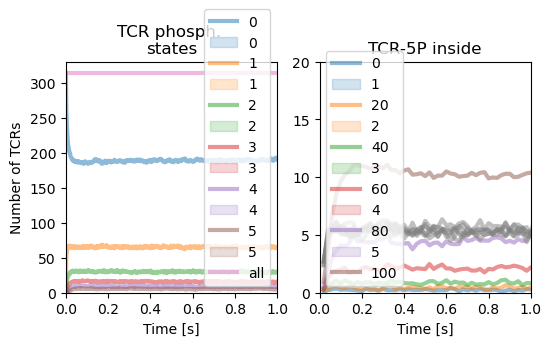

In [ ]:
fig, ax = plt.subplots(1,2, figsize = (6,3))
for iP in range(6):
    sns.lineplot(data=avgdat.loc[(avgdat['k_CD45']==0.01) & (avgdat['k_lck']==0.01) & (avgdat['CD45_excl']==0)], x = 'time', y='tcr{}'.format(iP), alpha=0.5, ax=ax[0], lw=3)
sns.lineplot(data=avgdat.loc[(avgdat['k_CD45']==0.01) & (avgdat['k_lck']==0.01) & (avgdat['CD45_excl']==0)], x = 'time', y='tcrall', alpha=0.5, ax=ax[0], lw=3)

ax[0].set_title('TCR phosph. \nstates')
ax[0].set_xlim(0,1)
#ax[0].set_xticks([0,15,30])
ax[0].set_ylim([0,330])
ax[0].set_ylabel('Number of TCRs')
ax[0].set_xlabel('Time [s]')
ax[0].legend([0,0,1,1,2,2,3,3,4,4,5,5,'all'])

for ie in CD45_exclusion:
    sns.lineplot(data=avgdat.loc[(avgdat['k_CD45']==0.01) & (avgdat['k_lck']==0.01) & (avgdat['CD45_excl']==ie) & (avgdat['tcr5i']>0)], x = 'time', y='tcr5i', alpha=0.5, ax=ax[1], lw=3)
for ie in CD45_exclusion:    
    sns.lineplot(data=avgdat.loc[(avgdat['k_CD45']==0.01) & (avgdat['k_lck']==0.01) & (avgdat['CD45_excl']==ie) & (avgdat['tcr5o']>0)], x = 'time', y='tcr5o', alpha=0.5, ax=ax[1], c='Gray', lw=3)

ax[1].set_title('TCR-5P inside')
ax[1].set_xlim(0,1)
#ax[1].set_xticks([0,15,30])
ax[1].set_ylim([0,20])
ax[1].set_ylabel('')
ax[1].set_xlabel('Time [s]')
ax[1].set_yticks([0,5,10,15,20])
ax[1].legend([0,1,20,2,40,3,60,4,80,5,100])
fig.savefig(fig_output_folder + 'FigS8F_Model2_5P_TCRs.svg')

### Fig S8G

In [ ]:
# TCR nP lifetimes

folder = "/Users/.../Model_2_5Phos_scan-e/"

filelist = [i for i in listdir(folder) if ('tcrs.txt' not in i) & ('model_2' in i) & ('lifetimes_5P' not in i)]
filelist = np.sort(filelist)
folder = Path(folder)

columnnames = ['time', 'tcr', 'tcrb', 'tcrp1', 'tcrp1b', 'tcrp2', 'tcrp2b', 'tcrp3', 'tcrp3b', 'tcrp4', 'tcrp4b', 'tcrp5', 'tcrp5b', 'tcrall', 'cd45all'] 
columnnames_tcrs = ['timestep', 'species_type', 'state', 'x', 'y', 'sn']


k_CD45 = 0.01 # s-1 um-2
k_lck = 0.01 # s-1 um-2
CD45_den = 600
pMHC_mdens = [0, 10]
CD45_exclusion = [0,20,40,60,80,100]
n_sim = 50
dt = 0.002 * 10

avg_lifetimes = pd.DataFrame()
for imhc in pMHC_mdens:
    avg = {
    'k_CD45': np.repeat(k_CD45, len(CD45_exclusion)),
    'k_lck': np.repeat(k_lck, len(CD45_exclusion)),
    'CD45_den': np.repeat(CD45_den, len(CD45_exclusion)),
    'CD45_excl': CD45_exclusion,
    'pMHC_mdens': np.repeat(imhc, len(CD45_exclusion)),
    }
    avg_lifetimes = pd.concat([avg_lifetimes, pd.DataFrame(avg)], ignore_index=True)
avg_lifetimes['tcr5_lifetimes_in'] = [[] for _ in range(avg_lifetimes.shape[0])]
avg_lifetimes['tcr5_lifetimes_out'] = [[] for _ in range(avg_lifetimes.shape[0])]
avg_lifetimes['tcr_dwell_times'] = [[] for _ in range(avg_lifetimes.shape[0])]
avg_lifetimes['trig_cross'] = [[] for _ in range(avg_lifetimes.shape[0])]

for ifile in filelist:
    if '_cd45.txt' in ifile:
        continue
    if check_metadata_file(ifile, [CD45_den],pMHC_mdens,CD45_exclusion,[k_CD45],[k_lck]):
        print(ifile)
        dat, tracks, metadata, lifetimes = read_sim_output(ifile, folder, columnnames, columnnames_tcrs, dt=dt, lifetimes_postfix = '_tcr_lifetimes_5P_0.1.json')
        cond = (avg_lifetimes['k_CD45']==metadata['k_CD45'].values[0]) & (avg_lifetimes['k_lck']==metadata['k_lck'].values[0]) & (avg_lifetimes['CD45_den']==metadata['CD45_den'].values[0]) & (avg_lifetimes['CD45_excl']==metadata['CD45_exclusion'].values[0]) & (avg_lifetimes['pMHC_mdens']==metadata['pMHC_mdens'].values[0])

        [avg_lifetimes.loc[cond, 'tcr5_lifetimes_in'].values[0].append(i*dt) for i in lifetimes['tcrp5_lifetimes_inside'].values[0]]
        [avg_lifetimes.loc[cond, 'tcr5_lifetimes_out'].values[0].append(i*dt) for i in lifetimes['tcrp5_lifetimes_outside'].values[0]]
        [avg_lifetimes.loc[cond, 'tcr_dwell_times'].values[0].append(i*dt) for i in lifetimes['tcr_dwell_times'].values[0]]
        [avg_lifetimes.loc[cond, 'trig_cross'].values[0].append(i*dt) for i in lifetimes['tcrp5_trig_cross'].values[0]]


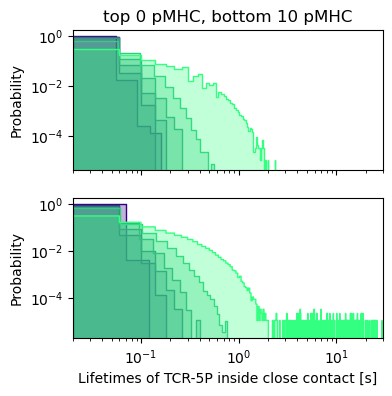

In [ ]:
# lifetime histograms per simulation plotted on top of each other
fig, ax = plt.subplots(2,1, figsize=(4,4))

for i,i_dat in avg_lifetimes[avg_lifetimes['pMHC_mdens']==0].iterrows():
    sns.histplot(data=i_dat['tcr5_lifetimes_in'], stat='probability', binwidth=0.04, ax=ax[0], element='step', alpha=0.3, color=(0.2,i_dat['CD45_excl']/100,0.5)) # np.array(i_dat['tcr5_lifetimes_in'])[np.where(np.array(i_dat['trig_cross']) == 0)[0]]
for i,i_dat in avg_lifetimes[avg_lifetimes['pMHC_mdens']==10].iterrows():
    sns.histplot(data=i_dat['tcr5_lifetimes_in'], stat='probability', binwidth=0.04, ax=ax[1], element='step', alpha=0.3, color=(0.2,i_dat['CD45_excl']/100,0.5)) # np.array(i_dat['tcr5_lifetimes_out'])[np.where(np.array(i_dat['trig_cross']) == 0)[0]]

ax[0].set_title('top 0 pMHC, bottom 10 pMHC')
ax[0].set_xlim([0.02,30])
ax[0].set_yscale('log')
ax[0].set_xscale('log')
ax[0].set_xticklabels('')

ax[1].set_xlim([0.02,30])
ax[1].set_yscale('log')
ax[1].set_xscale('log')
ax[1].set_xlabel('Lifetimes of TCR-5P inside close contact [s]')    
fig.savefig(fig_output_folder + 'FigS8G_Model2_5P_TCR-lifetimes.svg')

### Fig S8H

In [ ]:
folder = "/Users/.../Model_2_5Phos_scan-e/"

columnnames = ['time', 'tcr', 'tcrb', 'tcrp1', 'tcrp1b', 'tcrp2', 'tcrp2b', 'tcrp3', 'tcrp3b', 'tcrp4', 'tcrp4b', 'tcrp5', 'tcrp5b', 'tcrall', 'cd45all'] 
columnnames_tcrs = ['timestep', 'species_type', 'state', 'x', 'y', 'sn']

filelist = [i for i in listdir(folder) if ('tcrs.txt' not in i) & ('model_2' in i) & ('lifetimes_5P' not in i) & ('_cd45.txt' not in i)]
filelist = np.sort(filelist)
folder = Path(folder)

alldat = pd.DataFrame()

k_CD45 = [0.01] # s-1 um-2
k_lck = [0.01] # s-1 um-2
CD45_den = [600]
pMHC_mdens = [0,10]
CD45_exclusion = [0,20,40,60,80,100]
sel_lifetimes = [0.1, 0.2, 0.3, 0.4, 0.5]

triggering = pd.DataFrame()

for ifile in filelist:
    if check_metadata_file(ifile, CD45_den,pMHC_mdens,CD45_exclusion,k_CD45,k_lck):
        print(ifile)
        for ilife in sel_lifetimes:
            dat, tracks, metadata, lifetimes = read_sim_output(ifile, folder, columnnames, columnnames_tcrs, lifetimes_postfix = '_tcr_lifetimes_5P_{}.json'.format(ilife))

            # Unbound TCRP3
            tcrp5_trig_time = [i for i in lifetimes['tcrp5_trig_times'].values[0] if (i != False)] # to consider all triggering TCRs
            #trigtimes_p3 = lifetimes['tcrp3_trig_times'].values[0]
            #tcrp3_trig_time = [trigtimes_p3[i] for i in range(len(trigtimes_p3)) if ((trigtimes_p3[i] != False) and (lifetimes['tcrp3_trig_inside'].values[0][i]))] # to consider triggering TCRs only inside the contact
            if len(tcrp5_trig_time) > 0:
                tcrp5_trig_time = np.min(tcrp5_trig_time)*dt*10
            else:
                tcrp5_trig_time = simtime + 1
            tcrp5_lifetimes_inside_mean = lifetimes['tcrp5_lifetimes_inside'].values[0]
            if len(tcrp5_lifetimes_inside_mean) > 0:
                tcrp5_lifetimes_inside_mean = np.mean(tcrp5_lifetimes_inside_mean)*dt*10
            else: 
                tcrp5_lifetimes_inside_mean = 0

            # Bound TCRP3
            tcrp5b_trig_time = [i for i in lifetimes['tcrp5b_trig_times'].values[0] if (i != False)] # to consider all triggering TCRs
            #trigtimes_p3b = lifetimes['tcrp3b_trig_times'].values[0]
            #tcrp3b_trig_time = [trigtimes_p3b[i] for i in range(len(trigtimes_p3b)) if ((trigtimes_p3b[i] != False) and (lifetimes['tcrp3b_trig_inside'].values[0][i]))] # to consider triggering TCRs only inside the contact
            if len(tcrp5b_trig_time) > 0:
                tcrp5b_trig_time = np.min(tcrp5b_trig_time)*dt*10
            else:
                tcrp5b_trig_time = simtime + 1
            tcrp5b_lifetimes_inside_mean = lifetimes['tcrp5b_lifetimes_inside'].values[0]
            if len(tcrp5b_lifetimes_inside_mean) > 0:
                tcrp5b_lifetimes_inside_mean = np.mean(tcrp5b_lifetimes_inside_mean)*dt*10
            else: 
                tcrp5b_lifetimes_inside_mean = 0

            # Create dict
            trig = {
                'model': metadata['model'].values[0],
                'CD45_den':  metadata['CD45_den'].values[0],
                'pMHC_mdens': metadata['pMHC_mdens'].values[0],
                'k_off': metadata['k_off'].values[0],
                'k_CD45': metadata['k_CD45'].values[0],
                'CD45_exclusion': metadata['CD45_exclusion'].values[0],
                'k_lck': metadata['k_lck'].values[0],
                'repeat': metadata['repeat'].values[0],
                'tcrp5_trig_time': tcrp5_trig_time,
                'tcrp5b_trig_time': tcrp5b_trig_time,
                'tcrp5_lifetimes_inside_mean': tcrp5_lifetimes_inside_mean,
                'tcrp5b_lifetimes_inside_mean': tcrp5b_lifetimes_inside_mean,
                'lifetime': ilife,
            }
            triggering = pd.concat([triggering, pd.DataFrame(trig, index=[0])], ignore_index=True)

In [393]:
search_time = 20 # s

avgtrig = pd.DataFrame()
for ilife in sel_lifetimes:
    for ik in k_CD45:
        for jk in k_lck:
            for id in CD45_den:
                for ie in CD45_exclusion:
                    cond_pos = (triggering['k_CD45']==ik) & (triggering['k_lck']==jk) & (triggering['CD45_den']==id) & (triggering['CD45_exclusion']==ie) & (triggering['pMHC_mdens']==10) & (triggering['lifetime']==ilife)
                    cond_neg = (triggering['k_CD45']==ik) & (triggering['k_lck']==jk) & (triggering['CD45_den']==id) & (triggering['CD45_exclusion']==ie) & (triggering['pMHC_mdens']==0) & (triggering['lifetime']==ilife)
                    tp = np.sum(triggering.loc[cond_pos,'tcrp5_trig_time']<search_time)
                    fn = np.sum(triggering.loc[cond_pos,'tcrp5_trig_time']>=search_time)
                    fp = np.sum(triggering.loc[cond_neg,'tcrp5_trig_time']<search_time)
                    tn = np.sum(triggering.loc[cond_neg,'tcrp5_trig_time']>=search_time)
                    tpr = tp / len(triggering.loc[cond_pos,'tcrp5_trig_time'])
                    fpr = fp / len(triggering.loc[cond_neg,'tcrp5_trig_time'])
                    stat_mcc = mcc(tp, tn, fp, fn)
                    
                    avg = {
                        'k_CD45': ik,
                        'k_lck': jk,
                        'CD45_den': id,
                        'CD45_exclusion': ie,
                        'tcrp5_trig_time_mean_pos': np.mean(triggering.loc[cond_pos,'tcrp5_trig_time']),
                        'tcrp5b_trig_time_mean_pos': np.mean(triggering.loc[cond_pos,'tcrp5b_trig_time']),
                        'tcrp5_trig_time_mean_neg': np.mean(triggering.loc[cond_neg,'tcrp5_trig_time']),
                        'tcrp5b_trig_time_mean_neg': np.mean(triggering.loc[cond_neg,'tcrp5b_trig_time']),
                        'tp': tp,
                        'fn': fn, 
                        'tn': tn,
                        'fp': fp,
                        'tpr': tpr,
                        'fpr': fpr,
                        'stat': tpr * (1-fpr),
                        'mcc': stat_mcc,
                        'lifetime': ilife,
                    }
                    avgtrig = pd.concat([avgtrig, pd.DataFrame(avg, index=[0])], ignore_index=True)

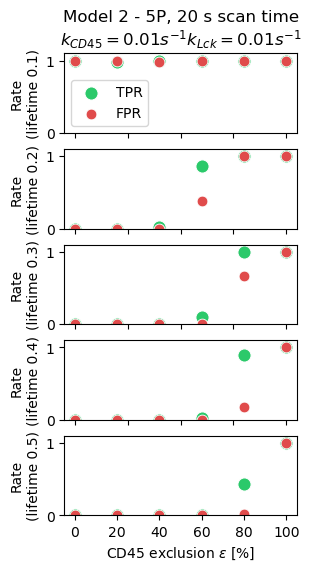

In [ ]:
fig, ax = plt.subplots(5,1,figsize = (3,6))

for i, ilife in enumerate(sel_lifetimes):

    cond = (avgtrig['k_CD45']==0.01) & (avgtrig['k_lck']==0.01) & (avgtrig['CD45_den']==600) & (avgtrig['lifetime']==ilife)

    sns.scatterplot(
        data=avgtrig.loc[cond],
        x='CD45_exclusion',
        y='tpr',
        ax = ax[i], 
        s=90,
        c='#2BC96A'
    )
    sns.scatterplot(
        data=avgtrig.loc[cond],
        x='CD45_exclusion',
        y='fpr',
        ax = ax[i], 
        alpha=1,
        s=60,
        c='#E04B4B'
    )
    ax[i].set_xticklabels('')
    ax[i].set_ylim([0,1.1])
    ax[i].set_ylabel('Rate\n(lifetime {})'.format(ilife))
    ax[i].set_xlabel('CD45 exclusion $\epsilon$ [%]') 
ax[4].set_xticks([0,20,40,60,80,100])
ax[4].set_xticklabels(['0','20','40','60','80','100'])
ax[0].set_title('Model 2 - 5P, 20 s scan time\n$k_{CD45} = 0.01 s^{-1} k_{Lck} = 0.01 s^{-1}$')
ax[0].legend(['TPR', 'FPR'])
fig.savefig(fig_output_folder + 'FigS8H_Model2_lifetimes_200scan.svg')

### Fig S8I

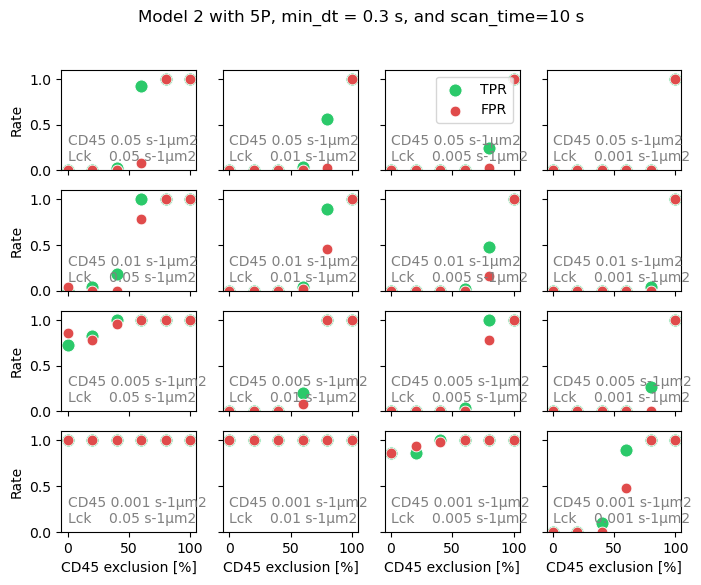

In [ ]:
# Plot FP etc. for varying k_CD45 and k_lck

k_CD45 = [0.05, 0.01, 0.005, 0.001] # s-1 um-2 [0.001,0.005,0.01,0.05] #
k_lck = [0.05, 0.01, 0.005, 0.001] # s-1 um-2 [0.001,0.005,0.01,0.05] #

fig, ax = plt.subplots(4,4, figsize=(8,6))
for i, i_CD45 in enumerate(k_CD45):
    for j, j_lck in enumerate(k_lck):
        cond = (avgtrig['k_CD45']==i_CD45) & (avgtrig['k_lck']==j_lck) & (avgtrig['CD45_den']==600)
        sns.scatterplot(
            data=avgtrig.loc[cond], 
            x='CD45_exclusion', 
            y='tpr', 
            ax=ax[i,j], 
            legend=False, 
            s=90,
            c='#2BC96A')
        sns.scatterplot(
            data=avgtrig.loc[cond], 
            x='CD45_exclusion', 
            y='fpr', 
            ax=ax[i,j], 
            legend=False, 
            s=60,
            c='#E04B4B')
        ax[i,j].set_ylim([0, 1.1])
        ax[i,j].text(0,0.1,'CD45 {} s-1µm2\nLck    {} s-1µm2'.format(i_CD45, j_lck), c='gray')

        if i+1 != len(k_CD45):
            ax[i,j].set_xticklabels('')
            ax[i,j].set_xlabel('')
        else:
            ax[i,j].set_xlabel('CD45 exclusion [%]')
        if j > 0:
            ax[i,j].set_yticklabels('')
            ax[i,j].set_ylabel('')
        else:
            ax[i,j].set_ylabel('Rate')

ax[0,2].legend(['TPR', 'FPR'])
fig.suptitle('Model 2 with 5P, min_dt = 0.3 s, and scan_time={} s'.format(scan_time))
fig.savefig(fig_output_folder + 'FigS8I_Model2_kCD45_kLck_scan.svg')